# Логистическая регрессия с нуля: классификация спама

В этом ноутбуке мы:

1. вспомним, чем дискриминативные модели отличаются от генеративных;
2. разберем логиты, сигмоиду и softmax;
3. вручную обучим логистическую регрессию на небольшом наборе сообщений;
4. классифицируем новое сообщение;
5. посмотрим на веса признаков и их интерпретацию;
6. проверим результат с помощью `scikit-learn`;
7. сравним логистическую регрессию и Naive Bayes.

Для краткости сообщения, не являющиеся спамом, будем обозначать как **Ham**. Класс `Spam` будем кодировать единицей, класс `Ham` — нулем.

## 1. Генеративные и дискриминативные модели

В предыдущем ноутбуке разобран Naive Bayes. Это **генеративная** модель: она оценивает правдоподобие $P(x\mid y)$ и априорную вероятность $P(y)$, а класс вычисляется по формуле Байеса:

$$
P(y\mid x)=
\frac{P(x\mid y)P(y)}{P(x)}.
$$

Логистическая регрессия — **дискриминативная** модель. Она не моделирует, как данные порождаются внутри класса, а сразу оценивает условную вероятность $P(y\mid x)$.

- Генеративный подход отвечает на вопрос: **«Какой класс лучше объясняет текст?»**
- Дискриминативный подход отвечает на вопрос: **«К какому классу относится текст?»**

Дискриминативная модель напрямую ищет границу между классами и использует ее для решения.

## 2. Логиты

Признаки представим в виде вектора:

$$
x=(x_1,x_2,\ldots,x_n).
$$

Для текстов $x_w$ — количество вхождений слова $w$ в сообщение. Логистическая регрессия вычисляет **логит** (score) — взвешенную сумму признаков:

$$
z=w^T x+b
=
\sum_{i=1}^{n}w_i x_i+b.
$$

Здесь:

- $z$ — логит: численная «уверенность» модели в пользу класса 1;
- $w_i$ — вес признака $x_i$ (параметры модели);
- $b$ — свободный член (bias).

Логит — произвольное вещественное число, $z\in(-\infty,+\infty)$. Это **не вероятность**. Превращает логит в вероятность сигмоида.

## 3. Сигмоида

Сигмоида, или логистическая функция:

$$
\sigma(z)=\frac{1}{1+e^{-z}}.
$$

Свойства сигмоиды:

- $\sigma(z)\in(0,1)$ — результат можно интерпретировать как вероятность;
- $\sigma(0)=1/2$ — нулевой логит соответствует «равновесию» между классами;
- при $z\to+\infty$ $\sigma(z)\to1$;
- при $z\to-\infty$ $\sigma(z)\to0$.

Вероятности классов:

$$
P(y=1\mid x)=\sigma(z)=\frac{1}{1+e^{-z}},
$$

$$
P(y=0\mid x)=1-\sigma(z)=\frac{e^{-z}}{1+e^{-z}}.
$$

Правило классификации: сообщение относится к `Spam`, если

$$
P(y=1\mid x)\ge 0.5,
$$

то есть если логит $z\ge 0$.

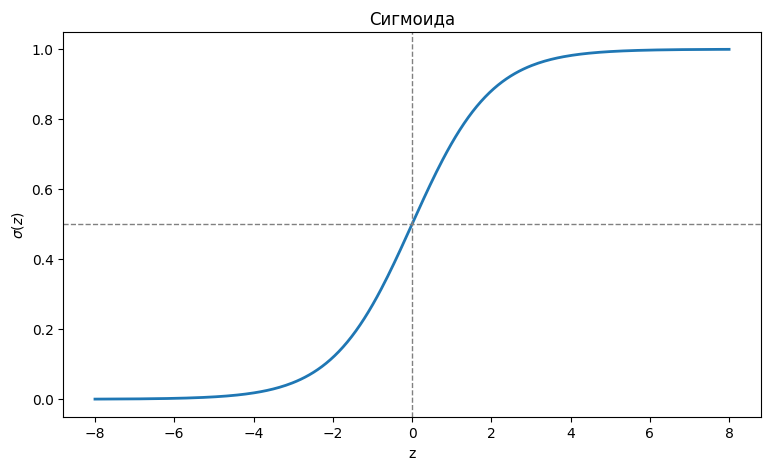

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 300)
p = sigmoid(z)

plt.figure(figsize=(9, 5))
plt.plot(z, p, color="tab:blue", linewidth=2)
plt.axhline(0.5, color="grey", linewidth=1, linestyle="--")
plt.axvline(0, color="grey", linewidth=1, linestyle="--")
plt.xlabel("z")
plt.ylabel(r"$\sigma(z)$")
plt.ylim(-0.05, 1.05)
plt.title("Сигмоида")
plt.show()

In [ ]:
# При больших отрицательных z наивная формула переполняется
z = -999
naive = 1 / (1 + np.exp(-z))   # np.exp(999) вызывает переполнение

print("Наивная формула при z = -999:", naive)

def stable_sigmoid(z):
    if z >= 0:
        return 1 / (1 + np.exp(-z))
    else:
        return np.exp(z) / (np.exp(z) + 1)

print("stable_sigmoid(-999):", stable_sigmoid(-999))
print("stable_sigmoid(999):", stable_sigmoid(999))

from scipy.special import expit
print("expit(-999):", expit(-999), " expit(999):", expit(999))

/var/folders/bn/64pnk_390pd8zfvbxld27hfw0000gn/T/ipykernel_85139/3614417408.py:3: RuntimeWarning: overflow encountered in exp
  naive = 1 / (1 + np.exp(-z))   # np.exp(999) вызывает переполнение


Наивная формула при z = -999: 0.0
stable_sigmoid(-999): 0.0
stable_sigmoid(999): 1.0


expit(-999): 0.0  expit(999): 1.0


### Softmax

Сигмоида — частный случай **softmax** для двух классов. В мультиклассовой задаче для каждого класса $k$ вычисляется свой логит:

$$
z_k=w_k^T x+b_k.
$$

Вероятность класса задается softmax:

$$
P(y=k\mid x)=
\frac{\exp(z_k)}{\sum_j\exp(z_j)}.
$$

Для двух классов $z_1=z$, $z_0=0$:

$$
P(y=1\mid x)=
\frac{e^{z}}{e^{0}+e^{z}}
=
\frac{1}{1+e^{-z}}
=
\sigma(z).
$$

Softmax превращает произвольные логиты в распределение вероятностей: все значения положительны и в сумме дают единицу.

In [ ]:
def stable_softmax(logits):
    logits = np.asarray(logits, dtype=float)
    z = logits - np.max(logits)   # вычислительная устойчивость
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z)

logits = np.array([0.5, -3.0, 2.0])
probs = stable_softmax(logits)

print("Логиты:", logits)
print("Вероятности:", np.round(probs, 4))
print("Сумма:", np.sum(probs))

Логиты: [ 0.5 -3.   2. ]
Вероятности: [0.1814 0.0055 0.8131]
Сумма: 1.0


## 4. Обучающая выборка

Рассмотрим четыре сообщения:

| ID | Сообщение | Класс |
|---|---|---|
| M1 | `buy cheap now` | Spam |
| M2 | `limited offer buy` | Spam |
| M3 | `meet me now` | Ham |
| M4 | `catch up soon` | Ham |

Будем классифицировать новое сообщение:

> `buy now`

In [ ]:
import pandas as pd

data = pd.DataFrame({
    "id": ["M1", "M2", "M3", "M4"],
    "text": [
        "buy cheap now",
        "limited offer buy",
        "meet me now",
        "catch up soon"
    ],
    "label": ["spam", "spam", "ham", "ham"]
})

data

,id,text,label
0,M1,buy cheap now,spam
1,M2,limited offer buy,spam
2,M3,meet me now,ham
3,M4,catch up soon,ham


In [ ]:
from collections import Counter

def tokenize(text):
    return text.lower().split()

data["y"] = data["label"].map({"spam": 1, "ham": 0})
data

,id,text,label,y
0,M1,buy cheap now,spam,1
1,M2,limited offer buy,spam,1
2,M3,meet me now,ham,0
3,M4,catch up soon,ham,0


## 5. Словарь и матрица признаков

Словарь состоит из всех уникальных слов обучающей выборки:

$$
V=\{\text{buy, catch, cheap, limited, me, meet, now, offer, soon, up}\}.
$$

Размер словаря:

$$
|V|=10.
$$

Признаком слова $w$ является количество вхождений $x_w$ в сообщение. Тогда логит сообщения:

$$
z=
\sum_{w\in V}\theta_w x_w+b.
$$

Матрица признаков $X$ имеет размерность $4\times10$.

In [ ]:
vocabulary = sorted({
    word
    for text in data["text"]
    for word in tokenize(text)
})

print("Словарь:", vocabulary)
print("Размер словаря:", len(vocabulary))

Словарь: ['buy', 'catch', 'cheap', 'limited', 'me', 'meet', 'now', 'offer', 'soon', 'up']
Размер словаря: 10


In [ ]:
def to_count_vector(text):
    counts = Counter(tokenize(text))
    return np.array([counts.get(word, 0) for word in vocabulary], dtype=float)

X = np.array([to_count_vector(text) for text in data["text"]])

feature_matrix = pd.DataFrame(X, columns=vocabulary, index=data["id"])
feature_matrix.index.name = "id"
feature_matrix

,buy,catch,cheap,limited,me,meet,now,offer,soon,up
id,,,,,,,,,,
M1,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
M2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
M3,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
M4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


## 6. Логистическая потеря

Модель должна выдавать вероятность $p=P(y=1\mid x)$, близкую к 1 для спама и к 0 для обычных сообщений. Логистическая потеря для одного наблюдения:

$$
\operatorname{loss}(y,p)=
\begin{cases}
-\log p, & y=1,\\
-\log(1-p), & y=0.
\end{cases}
$$

Эквивалентная форма:

$$
\operatorname{loss}(y,p)=-y\log p-(1-y)\log(1-p).
$$

Свойства:

- если модель уверенно права ($p=1$ при $y=1$ или $p=0$ при $y=0$), потеря равна 0;
- если модель уверенно ошибается, потеря стремится к бесконечности.

Средняя ошибка по выборке (log-loss):

$$
L=
-\frac{1}{N}\sum_{i=1}^{N}
\left(y_i\log p_i+(1-y_i)\log(1-p_i)\right).
$$

In [ ]:
def objective(y, p):
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

# Начальная модель: все веса равны нулю, поэтому p = sigma(0) = 0.5
y = data["y"].to_numpy()
n = data.shape[0]

print("Уровень ошибки при p = 0.5:", objective(y, np.full(n, 0.5)))

Уровень ошибки при p = 0.5: 0.6931471805599453


### График функции потерь

Слагаемое $-\log p$ отвечает за спам ($y=1$), слагаемое $-\log(1-p)$ — за обычные сообщения ($y=0$). Уверенная ошибка наказывается сильнее неуверенной.

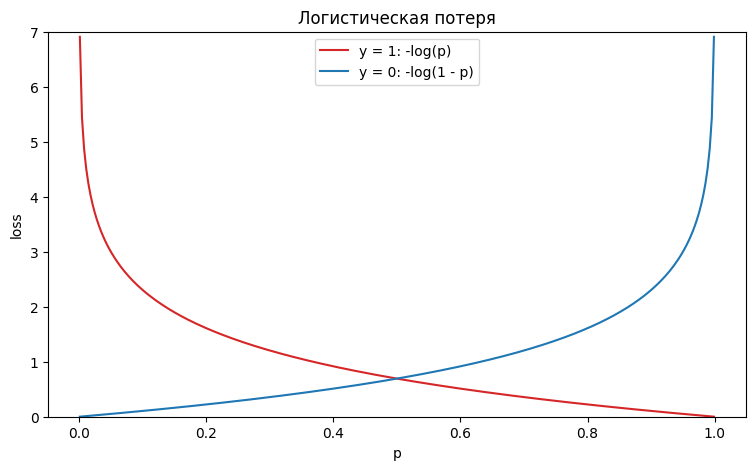

In [ ]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    p_grid = np.linspace(0.001, 0.999, 300)

    plt.figure(figsize=(9, 5))
    plt.plot(p_grid, -np.log(p_grid), color="tab:red",
             label="y = 1: -log(p)")
    plt.plot(p_grid, -np.log(1 - p_grid), color="tab:blue",
             label="y = 0: -log(1 - p)")
    plt.xlabel("p")
    plt.ylabel("loss")
    plt.ylim(0, 7)
    plt.title("Логистическая потеря")
    plt.legend(loc="upper center")
    plt.show()

## 7. Обучение: градиентный спуск

Функция потерь минимизируется градиентным спуском. Градиент по весам:

$$
\frac{\partial L}{\partial \theta}
=
\frac{1}{N}X^T(p-y),
$$

где $p=\sigma(X\theta)$ — вектор предсказаний, $y$ — вектор целевых значений, $N$ — число наблюдений.

Шаг градиентного спуска:

$$
\theta\leftarrow\theta-\eta\frac{\partial L}{\partial \theta},
$$

где $\eta$ — скорость обучения (learning rate).

Добавим столбец из единиц $x_0=1$. Тогда свободный член $b$ станет обычным весом $\theta_0$:

$$
z=\theta_0+\sum_{i=1}^{n}\theta_i x_i.
$$

In [ ]:
def add_ones(x):
    return np.column_stack([np.ones(x.shape[0]), x])

Xb = add_ones(X)

print("Матрица признаков с единичным столбцом:")
print(Xb)

Матрица признаков с единичным столбцом:
[[1. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0.]
 [1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0.]
 [1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1.]]


In [ ]:
def h(x, thetas):
    # прогноз модели: вероятность спама для каждого наблюдения
    return np.array([stable_sigmoid(value) for value in np.dot(x, thetas)])

def gradient(x, y, p, n):
    return np.dot(x.T, (p - y)) / n

In [ ]:
thetas = np.zeros(Xb.shape[1])
loss_history = []

for i in range(20000):
    p = h(Xb, thetas)
    loss_history.append(objective(y, p))
    thetas = thetas - 0.001 * gradient(Xb, y, p, n)

In [ ]:
print("Веса (свободный член, затем слова):")
print(thetas)
print("Финальный уровень ошибки:", loss_history[-1])

Веса (свободный член, затем слова):
[-0.18358593  1.67368297 -0.83264491  0.95202194  0.72166104 -1.02462399
 -1.02462399 -0.07260206  0.72166104 -0.83264491 -0.83264491]
Финальный уровень ошибки: 0.07563454574236644


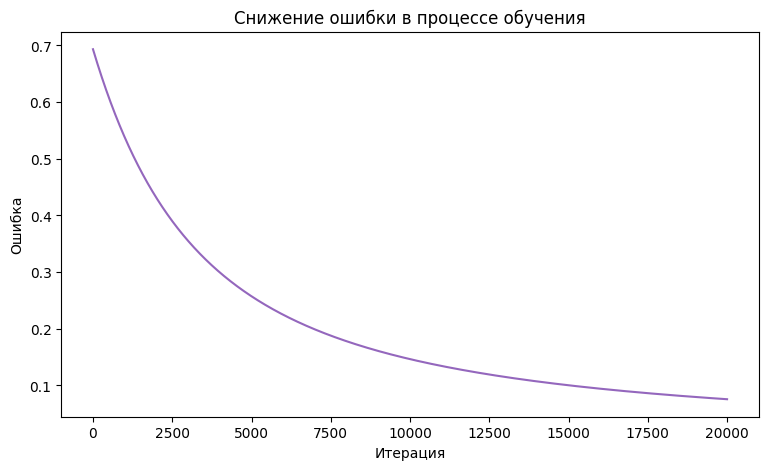

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(loss_history, color="tab:purple")
plt.xlabel("Итерация")
plt.ylabel("Ошибка")
plt.title("Снижение ошибки в процессе обучения")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

probabilities = h(Xb, thetas)
y_pred = (probabilities >= 0.5).astype(int)

print("Прогноз на обучающей выборке:", y_pred.tolist())
print("Accuracy:", accuracy_score(y, y_pred))

pd.DataFrame(
    confusion_matrix(y, y_pred),
    columns=["Forecast 0", "Forecast 1"],
    index=["Actual 0", "Actual 1"]
)

Прогноз на обучающей выборке: [1, 1, 0, 0]
Accuracy: 1.0


,Forecast 0,Forecast 1
Actual 0,2,0
Actual 1,0,2


## 8. Классификация нового сообщения

Новое сообщение:

> `buy now`

Его вектор признаков:

$$
x_{\text{buy}}=1,\quad x_{\text{now}}=1,\quad x_w=0\quad(w\ne\text{buy},w\ne\text{now}).
$$

Логит:

$$
z=\theta_{\text{buy}}\cdot1+\theta_{\text{now}}\cdot1+b.
$$

Вероятность спама:

$$
P(\text{Spam}\mid\text{``buy now''})=\sigma(z).
$$

In [ ]:
test_message = "buy now"

xtest = to_count_vector(test_message)
xtest_b = add_ones(xtest.reshape(1, -1))

z_test = np.dot(xtest_b[0], thetas)
p_spam = stable_sigmoid(z_test)

print("Вектор признаков:", xtest.astype(int))
print("Логит z:", z_test)
print("P(Spam | \"buy now\") =", p_spam)

Вектор признаков: [1 0 0 0 0 0 1 0 0 0]
Логит z: 1.41749498221419
P(Spam | "buy now") = 0.8049454082514047


In [ ]:
print("Слагаемые логита для сообщения \"buy now\":")
print("  вклад слова 'buy': ", thetas[1 + vocabulary.index("buy")])
print("  вклад слова 'now': ", thetas[1 + vocabulary.index("now")])
print("  свободный член b: ", thetas[0])
print("  итоговый логит z: ", z_test)

Слагаемые логита для сообщения "buy now":
  вклад слова 'buy':  1.6736829720540576
  вклад слова 'now':  -0.07260205748440185
  свободный член b:  -0.1835859323554656
  итоговый логит z:  1.41749498221419


## 9. Веса: значение и интерпретация

Каждому слову модель назначает свой вес $\theta_w$. Знак и величина веса показывают направление и силу влияния слова на логит:

- большой **положительный** вес повышает $z$ и отталкивает прогноз к `Spam`;
- большой **отрицательный** вес встречается у слов обычных сообщений и снижает $z$;
- вес, близкий к нулю, почти не влияет: слово `now` есть и в спаме, и в обычных сообщениях.

Классический пример из лекции: слово «бесплатно» получает большой положительный вес, а слово про рабочее совещание — отрицательный. Именно поэтому логистическая регрессия считается интерпретируемой моделью: вклад каждого слова виден прямо в весах.

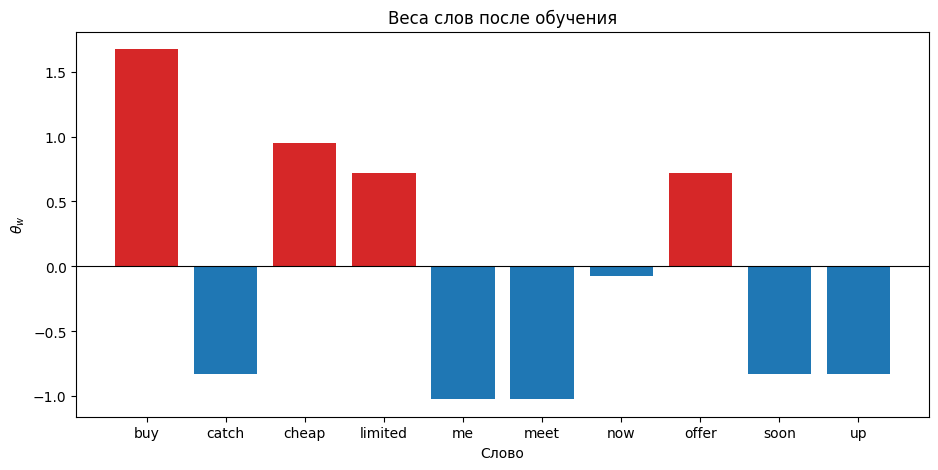

In [ ]:
plt.figure(figsize=(11, 5))
colors = ["tab:red" if w > 0 else "tab:blue" for w in thetas[1:]]
plt.bar(vocabulary, thetas[1:], color=colors)
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Слово")
plt.ylabel(r"$\theta_w$")
plt.title("Веса слов после обучения")
plt.show()

In [ ]:
word_weights = pd.Series(thetas[1:], index=vocabulary)

print("Слова, сильнее всего склоняющие к Spam:")
print(word_weights.sort_values(ascending=False).head(4).round(3).to_string())

print("\nСлова, сильнее всего склоняющие к Ham:")
print(word_weights.sort_values().head(4).round(3).to_string())

Слова, сильнее всего склоняющие к Spam:
buy        1.674
cheap      0.952
limited    0.722
offer      0.722

Слова, сильнее всего склоняющие к Ham:
me      -1.025
meet    -1.025
catch   -0.833
soon    -0.833


## 10. Проверка с помощью scikit-learn

В библиотеке `scikit-learn`:

- `CountVectorizer` строит словарь и считает вхождения слов;
- `LogisticRegression` минимизирует логистическую ошибку.

`LogisticRegression` по умолчанию добавляет $L_2$-регуляризацию и использует собственную схему оптимизации, поэтому точные значения весов и вероятностей могут немного отличаться от ручного обучения. Направления влияния слов и итоговый прогноз должны совпасть.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(data["text"])
y_train = data["label"]

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
X_test = vectorizer.transform([test_message])

prediction = model.predict(X_test)[0]
probabilities = model.predict_proba(X_test)[0]

probability_by_class = {
    str(class_name): round(float(probability), 4)
    for class_name, probability
    in zip(model.classes_, probabilities)
}

print("Сообщение:", test_message)
print("Классы модели:", model.classes_)
print("Вероятности:", probability_by_class)
print("Предсказанный класс:", prediction)

Сообщение: buy now
Классы модели: ['ham' 'spam']
Вероятности: {'ham': 0.3906, 'spam': 0.6094}
Предсказанный класс: spam


In [ ]:
sklearn_weights = pd.Series(
    model.coef_.ravel(),
    index=vectorizer.get_feature_names_out()
).sort_values()

print("Веса sklearn:")
print(sklearn_weights.round(3).to_string())

Веса sklearn:
me        -0.315
meet      -0.315
catch     -0.275
soon      -0.275
up        -0.275
now        0.003
limited    0.272
offer      0.272
cheap      0.318
buy        0.590


### Ручная модель и sklearn согласованы

- обе модели относят `buy now` к классу `Spam`;
- `buy`, `cheap`, `limited`, `offer` получают положительные веса;
- `me`, `meet`, `catch`, `soon`, `up` — отрицательные;
- вес слова `now` близок к нулю: оно встречается и в спаме, и в обычных сообщениях.

Расхождение в вероятностях (0.80 вручную и 0.61 в sklearn) объясняется $L_2$-регуляризацией и разными схемами оптимизации.

## 11. Naive Bayes или логистическая регрессия?

Для одних и тех же данных можно применить и Naive Bayes, и логистическую регрессию. Multinomial Naive Bayes из предыдущего ноутбука также отнес `buy now` к `Spam`, но с вероятностью 0.75.

### Основные различия

| Характеристика | Naive Bayes | Логистическая регрессия |
|---|---|---|
| Тип модели | Генеративная | Дискриминативная |
| Что моделируется | $P(x\mid y)$ и $P(y)$ | $P(y\mid x)$ напрямую |
| Обучение | Подсчет частот | Оптимизация весов |
| Допущение независимости слов | Да | Нет |
| Интерпретируемость | Высокая | Высокая |
| Скорость обучения | Очень высокая | Ниже (итеративная) |
| Хорошо работает при | малом объеме данных | достаточном объеме данных |
| Качество при больших данных | Обычно ниже | Обычно выше |

### Когда хорошо использовать логистическую регрессию

- цель — качество выше, чем у Naive Bayes, на достаточной выборке;
- признаки представлены как BoW или TF-IDF;
- нужен быстрый, интерпретируемый и хорошо откалиброванный вероятностный классификатор;
- важно контролировать переобучение регуляризацией.

### Когда лучше выбрать другой метод

- важен порядок слов или длинный контекст;
- нужны смысловые связи между словами (эмбеддинги, большие языковые модели);
- требуется максимально возможное качество на сложной задаче.

## 12. Итоги

### Итоговая классификация

Ручная модель:

$$
\boxed{P(\text{Spam}\mid\text{``buy now''})\approx 0.80}
$$

$$
\boxed{\text{``buy now''}\rightarrow\text{Spam}}
$$

Модель `scikit-learn` приходит к тому же решению.

### Ключевые шаги

1. признаки — счетчики вхождений слов $x_w$;
2. логит — взвешенная сумма признаков $z=\theta^T x+b$;
3. вероятность спама — сигмоида $P(y=1\mid x)=\sigma(z)$;
4. функция потерь — логистическая потеря (log-loss);
5. обучение — градиентный спуск;
6. предсказание — сравнение $P(\text{Spam}\mid x)$ с порогом 0.5.

### Главные выводы

1. Логистическая регрессия — дискриминативная модель: моделирует $P(y\mid x)$ напрямую.
2. Сигмоида превращает логит в вероятность; для нескольких классов она обобщается до softmax.
3. Логистическая потеря штрафует уверенные ошибки сильнее неуверенных.
4. Веса находятся градиентным спуском; знак и величина веса интерпретируются как вклад признака в решение.
5. Веса показывают, какое слово «тянет» сообщение к спаму, а какое — к обычным сообщениям.
6. Naive Bayes обучается быстрее (простой подсчет частот), логистическая регрессия обычно точнее на достаточно больших выборках.